In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
from shapely import Polygon

In [ ]:
#Importing the data into DataFrames
boredata= pd.read_csv("https://github.com/Matei-Stoica-Uni/Capstone-Case-Study---Australia/blob/main/Data/recharge-australia_data-bores.csv?raw=true")
griddata= pd.read_csv("https://github.com/Matei-Stoica-Uni/Capstone-Case-Study---Australia/blob/main/Data/recharge-australia_data-gridded-updated-soils.csv?raw=true")

In [3]:
data_coastlines = gpd.read_file('Data/f/GSHHS_f_L1.shp', engine='fiona')
data_lakes = gpd.read_file('Data/f/GSHHS_f_L2.shp', engine='fiona')
data_islands_in_lakes = gpd.read_file('Data/f/GSHHS_f_L3.shp', engine='fiona')

In [ ]:
data_coastlines

,id,level,source,parent_id,sibling_id,area,geometry
0,0-E,1,WVS,-1,-1,5.065405e+07,"POLYGON ((180 68.99378, 180 65.03378, 179.9983..."
1,0-W,1,WVS,-1,-1,5.065405e+07,"POLYGON ((-180 68.99378, -179.99844 68.99292, ..."
2,1,1,WVS,-1,-1,2.922097e+07,"POLYGON ((32.28292 31.2325, 32.2845 31.23281, ..."
3,2,1,WVS,-1,-1,2.015474e+07,"POLYGON ((-79.92628 9.31236, -79.92538 9.3124,..."
4,3,1,WVS,-1,-1,1.753416e+07,"POLYGON ((-73.36172 -53.00042, -73.36261 -53, ..."
...,...,...,...,...,...,...,...
179832,180501,1,WVS,-1,-1,5.542000e-04,"POLYGON ((-110.90125 78.73847, -110.89747 78.7..."
179833,180502,1,WVS,-1,-1,4.431505e-04,"POLYGON ((-105.70242 77.44856, -105.704 77.449..."
179834,180503,1,WVS,-1,-1,4.010580e-04,"POLYGON ((-79.96336 56.787, -79.96358 56.78694..."
179835,180504,1,WVS,-1,-1,2.612870e-04,"POLYGON ((-79.63522 56.86672, -79.63533 56.866..."


In [10]:
data_lakes

,id,level,source,parent_id,sibling_id,area,geometry
0,74892,2,WDBII,2310,-1,0.127490,"POLYGON ((145.76296 18.14529, 145.76483 18.141..."
1,180506,2,WDBII,0,-1,397052.350619,"POLYGON ((49.35167 39.32139, 49.35528 39.3175,..."
2,180507,2,WDBII,2,-1,208200.247285,"POLYGON ((-86.22917 42.99972, -86.22972 42.996..."
3,180508,2,WDBII,1,-1,69057.499143,"POLYGON ((31.61333 -2.04556, 31.61194 -2.04, 3..."
4,180509,2,WDBII,0,-1,67543.064239,"POLYGON ((61.45194 44.73556, 61.44306 44.72472..."
...,...,...,...,...,...,...,...
6655,187159,2,WDBII,1,-1,-81.969277,"POLYGON ((3.55972 11.75611, 3.56083 11.75194, ..."
6656,187160,2,WDBII,1,-1,-74.263796,"POLYGON ((-4.17194 14.64611, -4.17111 14.65222..."
6657,187161,2,WDBII,1,-1,-60.011426,"POLYGON ((0.75333 15.34889, 0.75111 15.34417, ..."
6658,187162,2,WDBII,0,-1,-54.268829,"POLYGON ((108.36972 15.855, 108.36806 15.85278..."


In [4]:
bbox_aus_corners = ((112,-10),(154,-10),(154,-44),(112,-44))
aus_bbox = Polygon(bbox_aus_corners)

In [ ]:
within_aus_coastlines = data_coastlines[data_coastlines.geometry.within(aus_bbox)]
within_aus_lakes = data_lakes[data_lakes.geometry.within(aus_bbox)]

<Axes: >

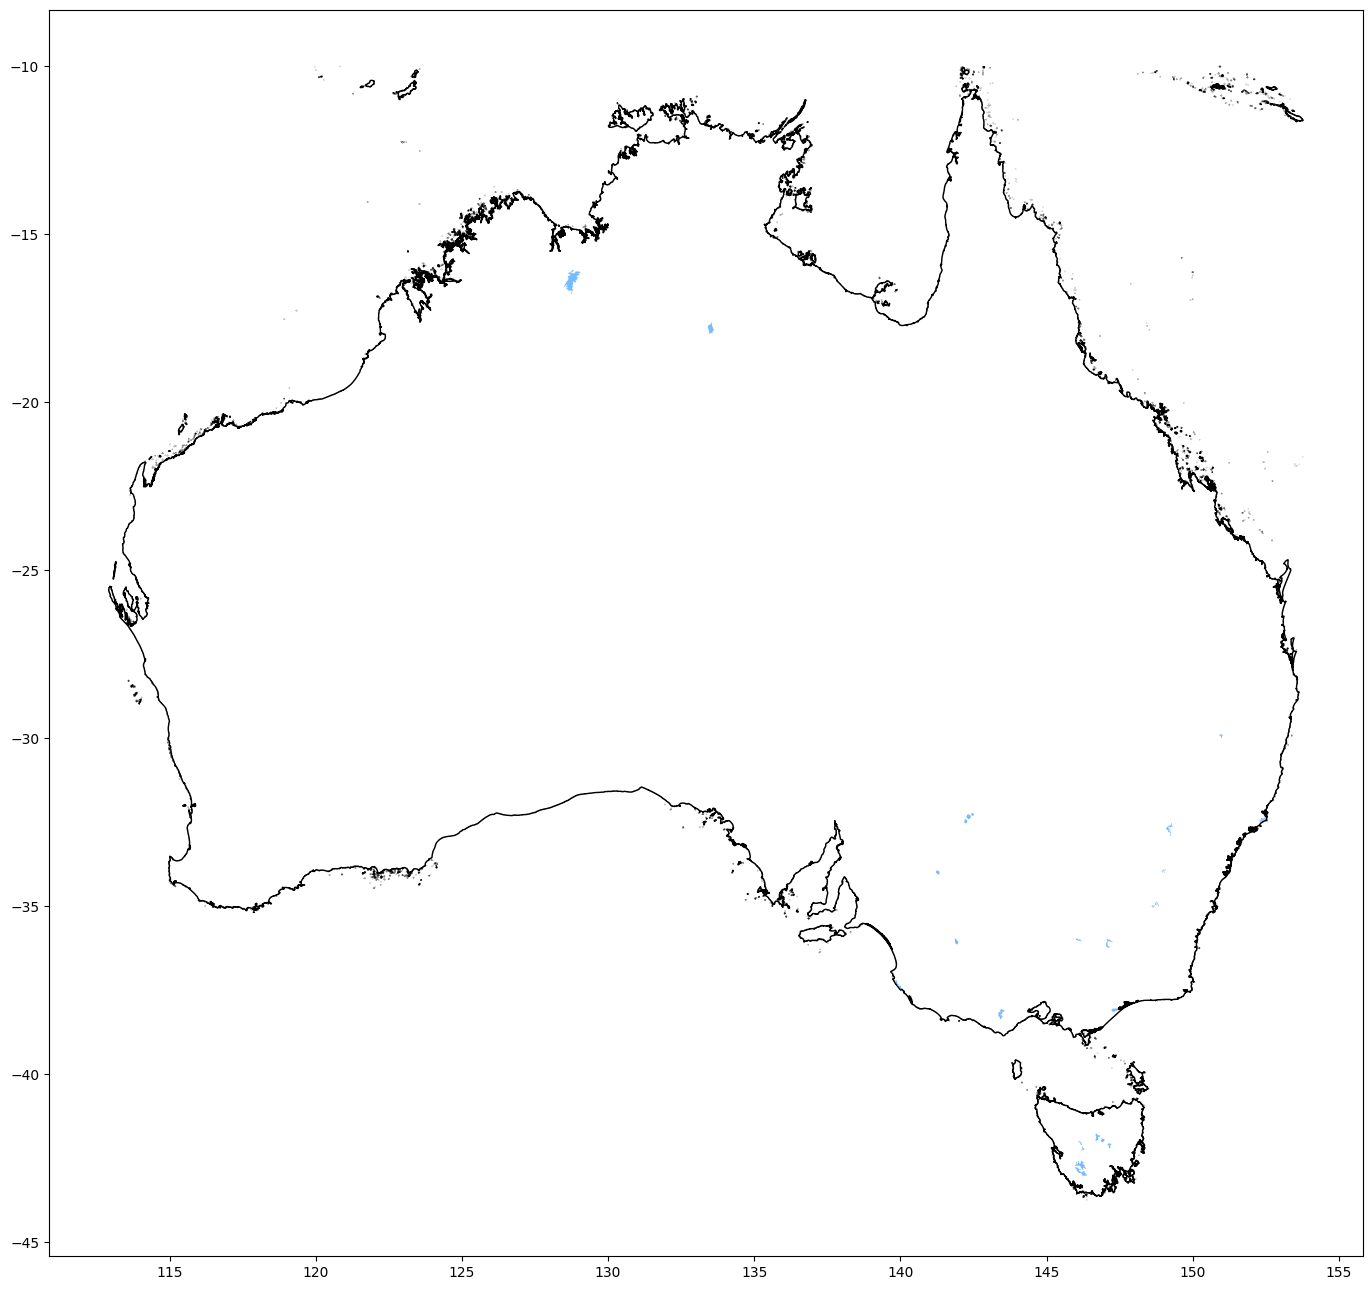

In [14]:
fig, ax = plt.subplots(figsize=(20,16.19))

within_aus_coastlines.plot(color='white',edgecolor='black',ax=ax)
within_aus_lakes.plot(color='xkcd:sky blue', ax=ax)